###**PROBLEM STATEMENT**

The given dataset containing below attributes for healthcare promotional data for social campaigns:

Input Variables:
1. campaign details
2. planned metrics
3. historical metrics


Output Variable:
1. roi_category

Predict roi_category (High / Medium / Low) for a campaign before it is launched.

In [115]:
#Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score


In [43]:
## Load the dataset
df=pd.read_csv('/content/promotional_social_outlets.csv')

In [44]:
df

,data_source_id,process_data_month,geography_name,product_name,category_type_name,disease_state_name,brand_name,channel_name,outlet_name,campaign_name,...,planned_impressions,planned_clicks,planned_ctr,historical_avg_ctr,historical_conversion_rate,budget_utilization,seasonality_index,audience_reach_score,engagement_expectation,roi_category
0,DS164,2025-02,India,Elagolix,Women's Health,Endometriosis,Orilissa,Display,Instagram,Patient Support,...,181932.0,5640.0,0.031006,0.082375,0.033874,0.778333,0.839990,0.729624,0.030023,Medium
1,DS036,2025-02,Canada,Elagolix,Women's Health,Endometriosis,Orilissa,Social Media,LinkedIn,Therapy Promotion,...,91090.0,1934.0,0.021235,0.097593,0.043298,0.684936,0.872730,0.591702,0.028255,Low
2,DS009,2025-01,India,Upadacitinib,Immunology,Psoriatic Arthritis,Rinvoq,Search,LinkedIn,Disease Education,...,308795.0,6603.0,0.021384,0.061982,0.025994,0.618666,1.189502,0.616386,0.015436,Medium
3,DS007,2025-09,USA,Elagolix,Women's Health,Endometriosis,Orilissa,Email,Instagram,Therapy Promotion,...,369030.0,29151.0,0.078994,0.057341,0.044398,0.872123,0.980200,0.506632,0.066532,High
4,DS151,2025-05,France,Adalimumab,Immunology,Rheumatoid Arthritis,Humira,Search,Twitter,Therapy Promotion,...,467113.0,12079.0,0.025860,0.074739,0.027606,0.648815,0.998071,0.517194,0.064559,High
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4237,DS192,2025-03,UK,Adalimumab,Immunology,Rheumatoid Arthritis,Humira,Email,Twitter,Early Diagnosis,...,242792.0,6031.0,0.024842,0.098677,0.024333,0.731505,0.836653,0.792821,0.045153,Low
4238,DS001,2025-07,Brazil,Risankizumab,Immunology,Psoriasis,Skyrizi,Display,Facebook,Disease Education,...,380328.0,24890.0,0.065446,0.080604,0.042391,0.954646,0.905214,0.612280,0.037930,High
4239,DS028,2025-09,Germany,Elagolix,Women's Health,Endometriosis,Orilissa,Display,LinkedIn,Therapy Promotion,...,215432.0,12151.0,0.056405,0.056220,0.041119,0.770183,0.861545,0.988208,0.024522,High
4240,DS099,2025-08,UK,Elagolix,Women's Health,Endometriosis,Orilissa,Social Media,YouTube,Awareness Drive,...,423938.0,25597.0,0.060381,0.044366,0.011425,0.974262,1.034448,0.649071,0.018948,Medium


###**EDA**

###a. Basic data check

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4242 entries, 0 to 4241
Data columns (total 21 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   data_source_id              4242 non-null   object 
 1   process_data_month          4242 non-null   object 
 2   geography_name              4242 non-null   object 
 3   product_name                4242 non-null   object 
 4   category_type_name          4242 non-null   object 
 5   disease_state_name          4242 non-null   object 
 6   brand_name                  4242 non-null   object 
 7   channel_name                4242 non-null   object 
 8   outlet_name                 4242 non-null   object 
 9   campaign_name               4242 non-null   object 
 10  cost                        4242 non-null   float64
 11  planned_impressions         4242 non-null   float64
 12  planned_clicks              4242 non-null   float64
 13  planned_ctr                 4114 

Dataset contains total 21 columns out of that 11 categorical columns and 10 float columns.  

In [5]:
df.shape

(4242, 21)

we have 4242 rows and 21 columns in dataset

In [6]:
## Basic statistical analysis
df.describe().T

,count,mean,std,min,25%,50%,75%,max
cost,4242.0,34704.765865,14555.732377,10014.000000,22095.250000,34347.000000,47223.250000,77663.300000
planned_impressions,4242.0,327189.086987,160164.604498,50005.000000,189687.500000,328462.000000,464562.500000,764986.300000
planned_clicks,4242.0,16303.118105,10151.575003,1050.000000,8057.250000,14454.500000,23238.500000,46498.000000
planned_ctr,4114.0,0.049785,0.017209,0.020001,0.035009,0.049596,0.064625,0.079983
historical_avg_ctr,4116.0,0.060278,0.023224,0.020000,0.040449,0.060411,0.080706,0.099991
historical_conversion_rate,4242.0,0.029912,0.011458,0.010007,0.020039,0.029794,0.039618,0.049942
budget_utilization,4116.0,0.800938,0.115210,0.600012,0.701944,0.801802,0.902454,0.999940
seasonality_index,4242.0,1.001716,0.116937,0.800123,0.900006,1.003240,1.101295,1.199784
audience_reach_score,4242.0,0.749740,0.144005,0.500034,0.622946,0.749903,0.871131,0.999734
engagement_expectation,4115.0,0.040111,0.017259,0.010014,0.025168,0.040213,0.054812,0.069994


It shows the basic statistics of the dataset.

**b.Delete all such columns that have all the values in it as unique.**

In [7]:
unique_cols = df.columns[df.nunique() == len(df)]
unique_cols

Index([], dtype='object')

No unique columns found in dataset.

In [45]:
df = df.drop(columns=["data_source_id"])

As data_source_id is a ID column there is no business meaning for prediction. Dropping irrelevant feature from dataset.

In [9]:
df

,process_data_month,geography_name,product_name,category_type_name,disease_state_name,brand_name,channel_name,outlet_name,campaign_name,cost,planned_impressions,planned_clicks,planned_ctr,historical_avg_ctr,historical_conversion_rate,budget_utilization,seasonality_index,audience_reach_score,engagement_expectation,roi_category
0,2025-02,India,Elagolix,Women's Health,Endometriosis,Orilissa,Display,Instagram,Patient Support,25795.0,181932.0,5640.0,0.031006,0.082375,0.033874,0.778333,0.839990,0.729624,0.030023,Medium
1,2025-02,Canada,Elagolix,Women's Health,Endometriosis,Orilissa,Social Media,LinkedIn,Therapy Promotion,26023.0,91090.0,1934.0,0.021235,0.097593,0.043298,0.684936,0.872730,0.591702,0.028255,Low
2,2025-01,India,Upadacitinib,Immunology,Psoriatic Arthritis,Rinvoq,Search,LinkedIn,Disease Education,16396.0,308795.0,6603.0,0.021384,0.061982,0.025994,0.618666,1.189502,0.616386,0.015436,Medium
3,2025-09,USA,Elagolix,Women's Health,Endometriosis,Orilissa,Email,Instagram,Therapy Promotion,11899.0,369030.0,29151.0,0.078994,0.057341,0.044398,0.872123,0.980200,0.506632,0.066532,High
4,2025-05,France,Adalimumab,Immunology,Rheumatoid Arthritis,Humira,Search,Twitter,Therapy Promotion,18433.0,467113.0,12079.0,0.025860,0.074739,0.027606,0.648815,0.998071,0.517194,0.064559,High
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4237,2025-03,UK,Adalimumab,Immunology,Rheumatoid Arthritis,Humira,Email,Twitter,Early Diagnosis,32614.0,242792.0,6031.0,0.024842,0.098677,0.024333,0.731505,0.836653,0.792821,0.045153,Low
4238,2025-07,Brazil,Risankizumab,Immunology,Psoriasis,Skyrizi,Display,Facebook,Disease Education,12586.0,380328.0,24890.0,0.065446,0.080604,0.042391,0.954646,0.905214,0.612280,0.037930,High
4239,2025-09,Germany,Elagolix,Women's Health,Endometriosis,Orilissa,Display,LinkedIn,Therapy Promotion,34911.0,215432.0,12151.0,0.056405,0.056220,0.041119,0.770183,0.861545,0.988208,0.024522,High
4240,2025-08,UK,Elagolix,Women's Health,Endometriosis,Orilissa,Social Media,YouTube,Awareness Drive,25852.0,423938.0,25597.0,0.060381,0.044366,0.011425,0.974262,1.034448,0.649071,0.018948,Medium


**c. Handling the null values**

In [10]:
## Handle null values
df.isnull().sum()

,0
process_data_month,0
geography_name,0
product_name,0
category_type_name,0
disease_state_name,0
brand_name,0
channel_name,0
outlet_name,0
campaign_name,0
cost,0


planned_ctr, historical_avg_ctr, budget_utilization,engagement_expectation columns have null values. These are the float values so replaced with mean value.

In [46]:
for col in ['planned_ctr', 'historical_avg_ctr', 'budget_utilization','engagement_expectation']:
    df[col] = df[col].fillna(df[col].mean())

In [47]:
df.isnull().sum()

,0
process_data_month,0
geography_name,0
product_name,0
category_type_name,0
disease_state_name,0
brand_name,0
channel_name,0
outlet_name,0
campaign_name,0
cost,0


All null values are replaced with mean values and now there is no null values present in dataset.

**d. Handling duplicates**

In [48]:
df.duplicated().sum()

np.int64(39)

There are 39 duplicate records present in dataset.

In [49]:
df.drop_duplicates(inplace=True)

In [50]:
df.duplicated().sum()

np.int64(0)

Duplicates are removed from dataset.

**e. Handling error values -   error values can be anything - "?", "/", "unknown", etc**

In [51]:
## Find out how many "?" are there in any columns

df.isin(['?','unknown','/']).sum()

,0
process_data_month,0
geography_name,0
product_name,0
category_type_name,0
disease_state_name,0
brand_name,0
channel_name,0
outlet_name,0
campaign_name,0
cost,0


No error values are present in dataset.

**f. Split the dataset into categorical and numerical column**

In [52]:
categorical_columns = df.select_dtypes(include = 'object').columns
numerical_columns = df.select_dtypes(exclude = 'object').columns

In [53]:
categorical_columns

Index(['process_data_month', 'geography_name', 'product_name',
       'category_type_name', 'disease_state_name', 'brand_name',
       'channel_name', 'outlet_name', 'campaign_name', 'roi_category'],
      dtype='object')

In [54]:
numerical_columns

Index(['cost', 'planned_impressions', 'planned_clicks', 'planned_ctr',
       'historical_avg_ctr', 'historical_conversion_rate',
       'budget_utilization', 'seasonality_index', 'audience_reach_score',
       'engagement_expectation'],
      dtype='object')

**g. Outliers**

In [55]:
## Outlier detection

def outlier_detection(df, column):
  Q1 = df[column].quantile(0.25)
  Q3 = df[column].quantile(0.75)
  IQR = Q3 - Q1
  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR

  return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

In [56]:
for col in numerical_columns:
  df = outlier_detection(df, col)

In [57]:
df.shape

(4198, 20)

Outliers are removed and rows are reduced to 4198.

**h. Convert categorical data to numerical data**

In [58]:
df["month"] = pd.to_datetime(df["process_data_month"]).dt.month
df.drop(columns=["process_data_month"], inplace=True)

We are extracting useful features from process data month. Extracting month only as year have same value for all. It will convert it to numerical features.

In [59]:
le=LabelEncoder()

In [60]:
le_d = {}

In [61]:
le_cat_cols = [
    "product_name",
    "category_type_name",
    "disease_state_name",
    "brand_name",
    "campaign_name",
    "roi_category"
]

In [62]:
for col in le_cat_cols:
  df[col] = le.fit_transform(df[col])  ## It will convert all the categorical data to numerical data
  le_d[col] = le  ## Saving the encoding for future use

In [63]:
le_d

{'product_name': LabelEncoder(),
 'category_type_name': LabelEncoder(),
 'disease_state_name': LabelEncoder(),
 'brand_name': LabelEncoder(),
 'campaign_name': LabelEncoder(),
 'roi_category': LabelEncoder()}

In [64]:
oh_enc_cols = [
    "geography_name",
    "channel_name",
    "outlet_name"
]

We have few unique values for above columns and one hot encoding prevents false ordering. So using One hot Encoder for above columns.

In [65]:
df = pd.get_dummies(df, columns=oh_enc_cols)

In [66]:
categorical_columns = df.select_dtypes(include = 'object').columns
numerical_columns = df.select_dtypes(exclude = 'object').columns

In [67]:
categorical_columns

Index([], dtype='object')

In [68]:
numerical_columns

Index(['product_name', 'category_type_name', 'disease_state_name',
       'brand_name', 'campaign_name', 'cost', 'planned_impressions',
       'planned_clicks', 'planned_ctr', 'historical_avg_ctr',
       'historical_conversion_rate', 'budget_utilization', 'seasonality_index',
       'audience_reach_score', 'engagement_expectation', 'roi_category',
       'month', 'geography_name_Brazil', 'geography_name_Canada',
       'geography_name_France', 'geography_name_Germany',
       'geography_name_India', 'geography_name_UK', 'geography_name_USA',
       'channel_name_Display', 'channel_name_Email', 'channel_name_Search',
       'channel_name_Social Media', 'outlet_name_Facebook',
       'outlet_name_Google', 'outlet_name_Instagram', 'outlet_name_LinkedIn',
       'outlet_name_Twitter', 'outlet_name_YouTube'],
      dtype='object')

**i. Univariate/Bivariate analysis of the features**

<Axes: xlabel='roi_category', ylabel='count'>

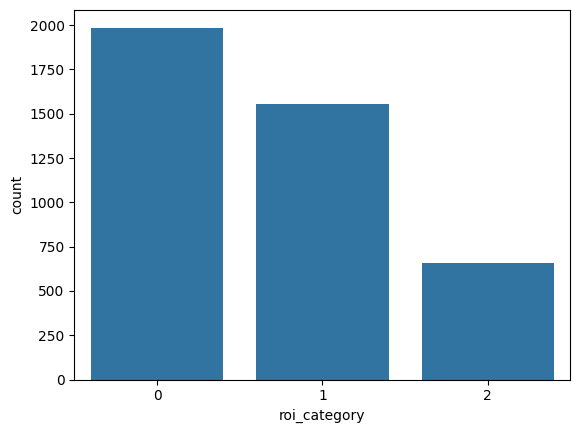

In [69]:
sns.countplot(x=df['roi_category'])

he target variable showed class imbalance, with the majority of campaigns falling into the low ROI category and fewer in the high ROI category.

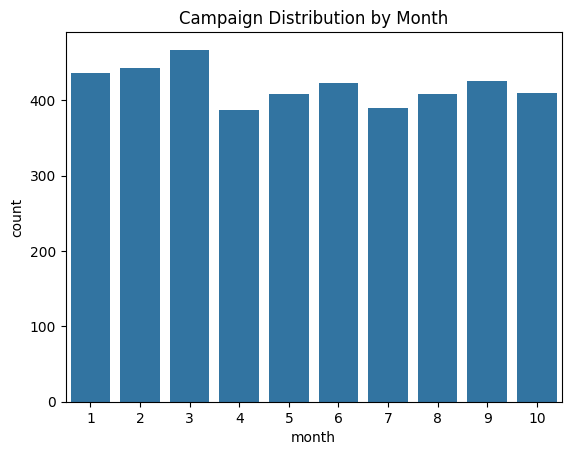

In [70]:
sns.countplot(x=df['month'])
plt.title("Campaign Distribution by Month")
plt.show()

Campaigns are evenly distributed across months. It shows slightly high in 3rd month as compared to others.

In [36]:
df.corr()

,product_name,category_type_name,disease_state_name,brand_name,campaign_name,cost,planned_impressions,planned_clicks,planned_ctr,historical_avg_ctr,...,channel_name_Display,channel_name_Email,channel_name_Search,channel_name_Social Media,outlet_name_Facebook,outlet_name_Google,outlet_name_Instagram,outlet_name_LinkedIn,outlet_name_Twitter,outlet_name_YouTube
product_name,1.000000,0.154392,-0.541073,0.351078,0.001203,0.005219,-0.037387,-0.024908,0.005979,0.000767,...,-0.017834,-0.017161,0.003565,0.031216,0.010060,0.001518,-0.003103,0.000823,-0.003134,-0.006149
category_type_name,0.154392,1.000000,-0.664993,0.080390,0.016469,0.003047,0.002634,0.015588,0.011573,-0.001387,...,-0.030011,0.011707,-0.003890,0.021875,0.006809,-0.029920,0.004234,-0.005829,0.009596,0.014578
disease_state_name,-0.541073,-0.664993,1.000000,0.217831,-0.000114,-0.010747,0.017689,-0.003569,-0.024267,-0.020757,...,0.017343,0.009298,-0.002863,-0.023608,0.008632,0.010663,0.003551,-0.002204,-0.002480,-0.018058
brand_name,0.351078,0.080390,0.217831,1.000000,0.001758,-0.011991,-0.020127,-0.015645,-0.004771,-0.039694,...,-0.005442,0.005621,-0.011204,0.010723,0.027070,-0.008717,0.005717,-0.002679,-0.001323,-0.020285
campaign_name,0.001203,0.016469,-0.000114,0.001758,1.000000,0.029378,-0.000712,-0.011251,-0.022255,0.001333,...,0.003315,-0.012926,-0.016532,0.025658,0.015999,0.016928,-0.016688,0.008014,0.000887,-0.024281
cost,0.005219,0.003047,-0.010747,-0.011991,0.029378,1.000000,-0.002215,-0.000448,-0.006316,-0.022898,...,-0.008010,0.001843,0.000935,0.005188,-0.007456,-0.028735,0.006454,0.012376,0.017062,0.000707
planned_impressions,-0.037387,0.002634,0.017689,-0.020127,-0.000712,-0.002215,1.000000,0.790956,0.023083,0.019643,...,0.003209,-0.004940,0.013816,-0.011735,0.020599,-0.003703,-0.012846,-0.003348,0.002629,-0.003311
planned_clicks,-0.024908,0.015588,-0.003569,-0.015645,-0.011251,-0.000448,0.790956,1.000000,0.557139,0.027210,...,0.009226,0.004098,0.009136,-0.022101,0.018123,-0.014638,-0.013835,-0.008524,0.015367,0.003528
planned_ctr,0.005979,0.011573,-0.024267,-0.004771,-0.022255,-0.006316,0.023083,0.557139,1.000000,0.010448,...,0.010880,0.023830,-0.008637,-0.026010,0.003171,-0.003315,-0.001794,-0.014093,0.012888,0.003004
historical_avg_ctr,0.000767,-0.001387,-0.020757,-0.039694,0.001333,-0.022898,0.019643,0.027210,0.010448,1.000000,...,-0.013897,-0.009335,0.014138,0.009248,-0.020348,0.022098,-0.006000,0.006119,-0.005201,0.003789


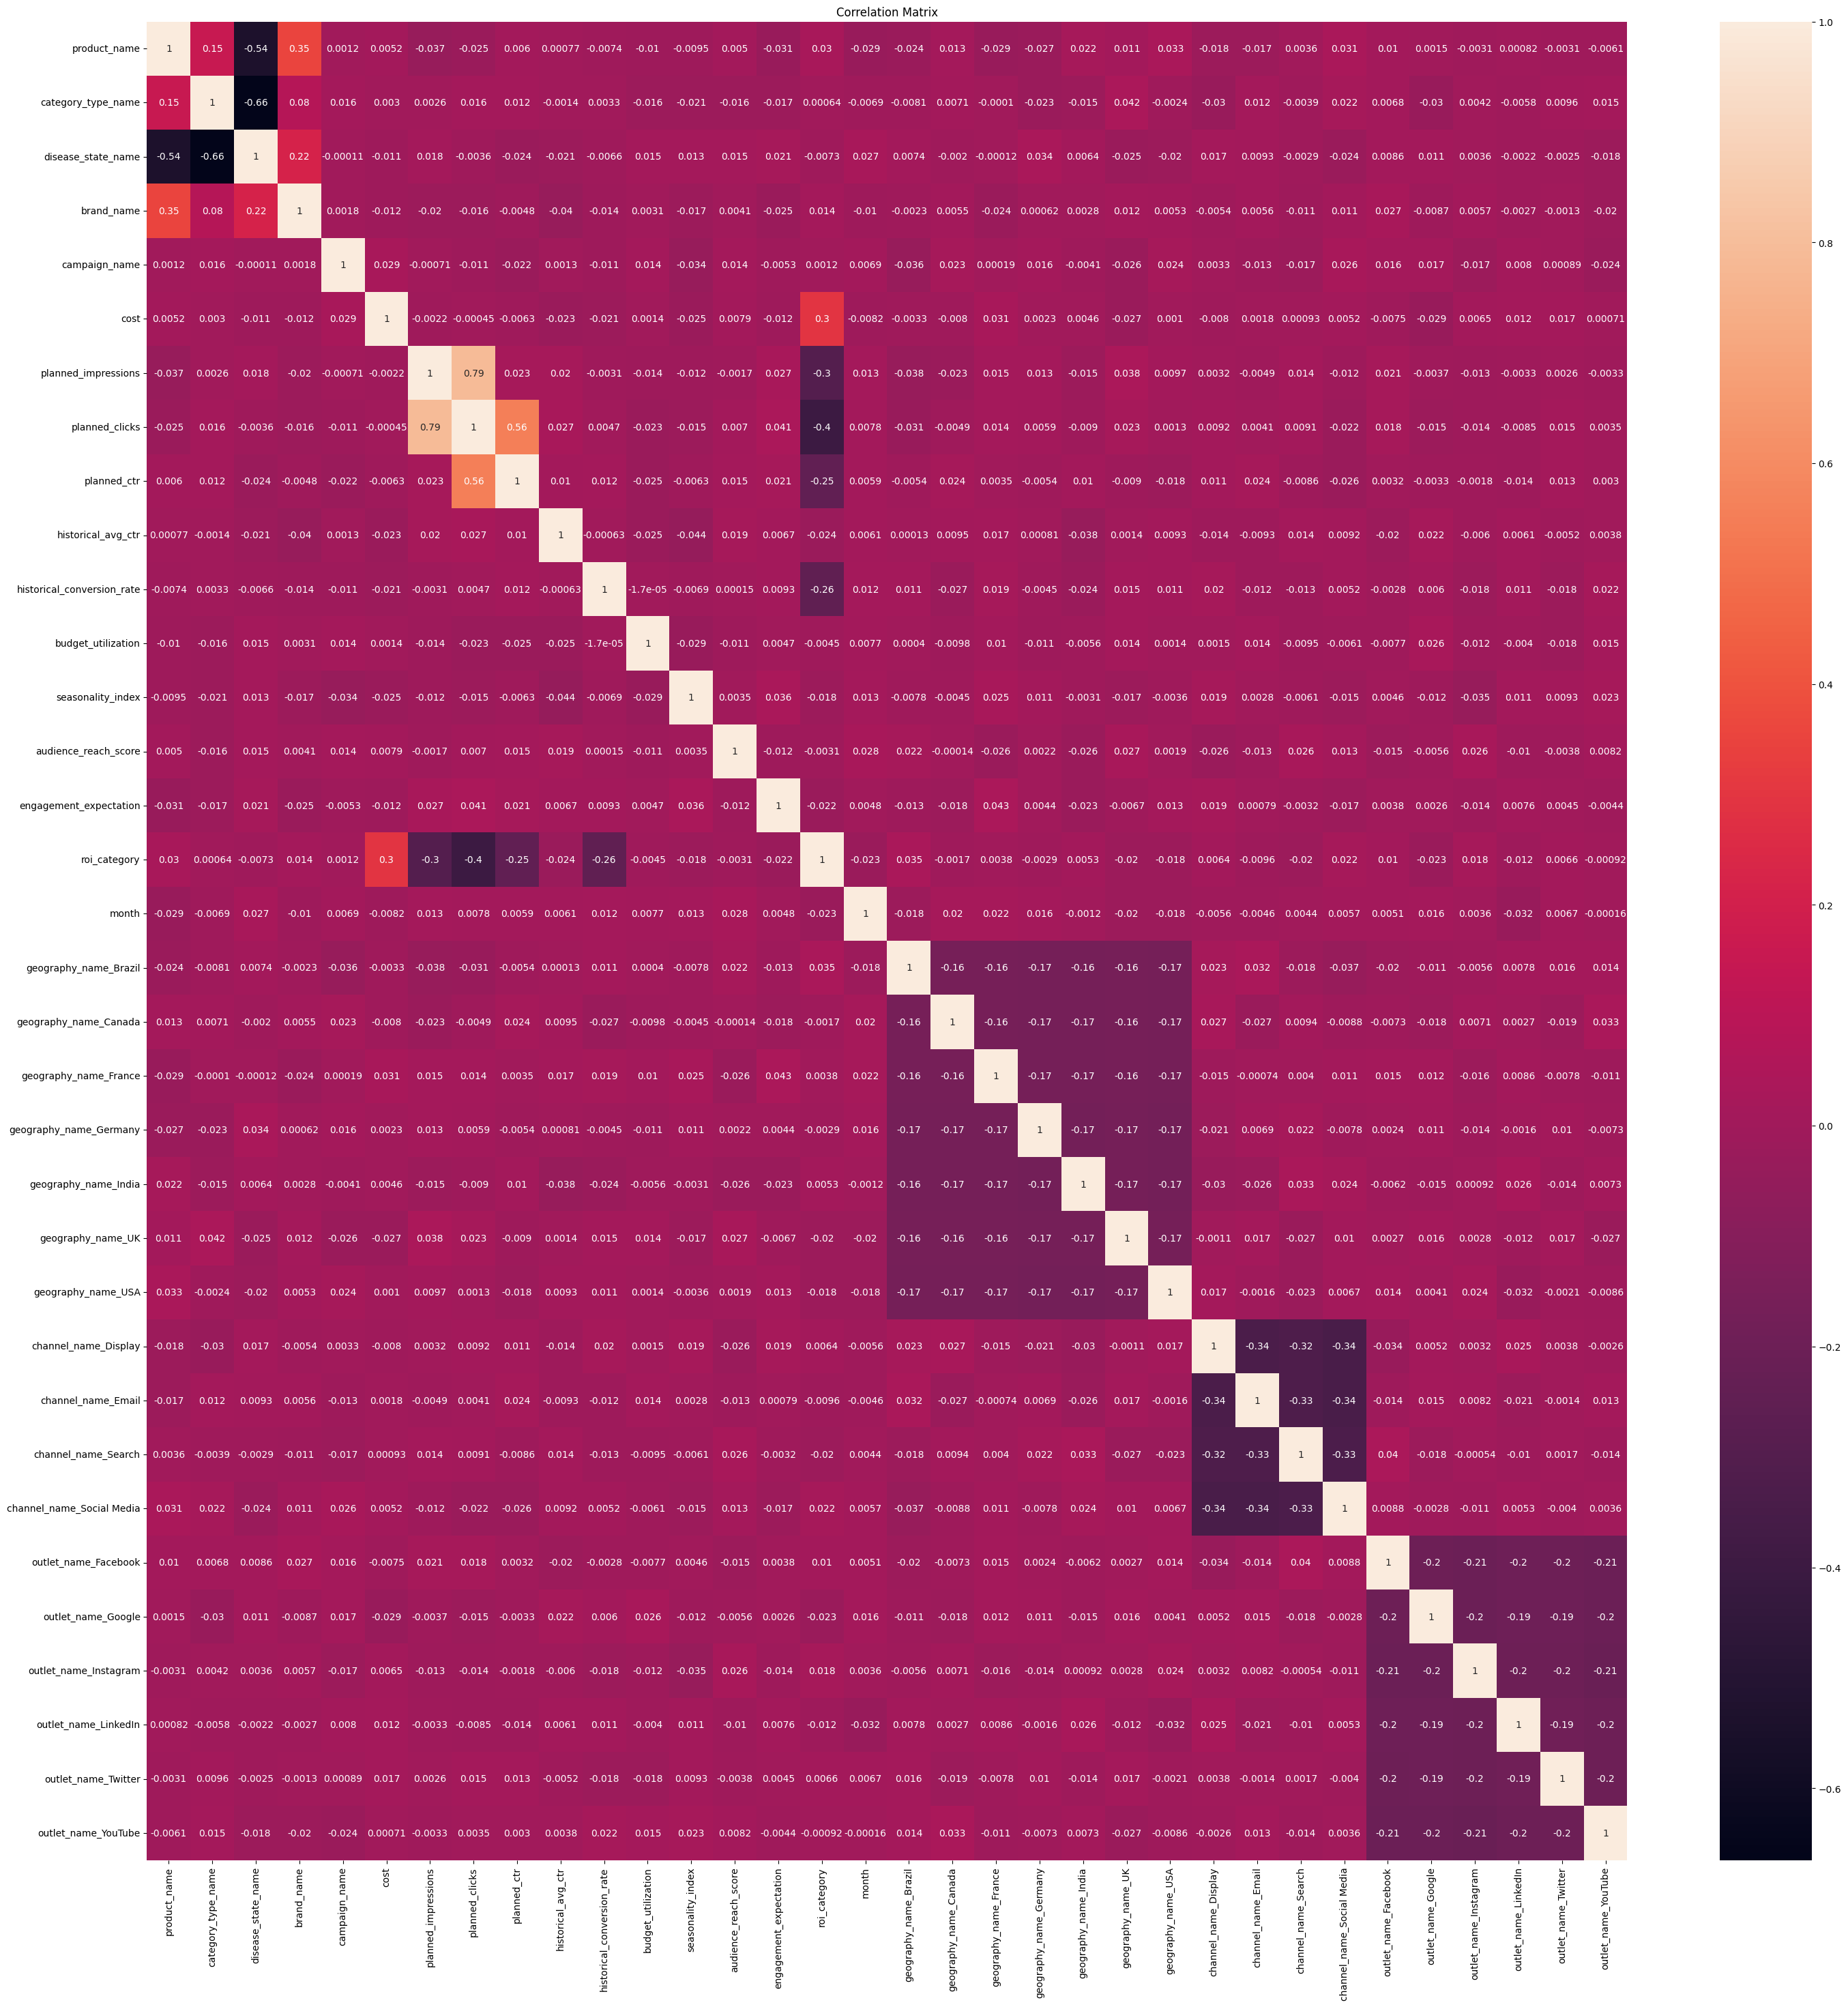

In [37]:
plt.figure(figsize=(35,35))   # increase size
sns.heatmap(df.corr(), annot=True)
plt.title("Correlation Matrix")
plt.show()

### Correlation Insights
1. **Strong Positive Correlation** : planned_impressions and planned_clicks (0.79), Higher impressions lead to more clicks (expected marketing behavior)
2. **Moderate Positive Correlation** :planned_clicks and planned_ctr (0.55), Click-through rate is directly related to number of clicks
3. **Strong Negative Correlation with Target**
planned_clicks (-0.39) and planned_impressions (-0.29). Higher volume campaigns may not always lead to higher ROI.
4. **Positive Correlation with Target** : cost (0.29)- Higher investment slightly increases chances of better ROI.
5. **Most Features Have Low Correlation** : indicates Features are relatively independent.


### **ML model building**

Define features (X) and output variable (y).

In [71]:
X = df.drop(columns=["roi_category"])
y = df["roi_category"]

In [72]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

It will split the dataset into X -train, y-train to train model and X-test, y-test to test model. Test size is 20% and train size is 80%.
random_state=42 - It will fix the randomness of split and give same split every time.

### Standardization

In [73]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [74]:
pca = PCA()

# Fit only on training data
X_train_pca = pca.fit_transform(X_train_scaled)

We learn PCA components only from training data

In [75]:
explained_variance = pca.explained_variance_ratio_

I6 will store the information for each compomnent.

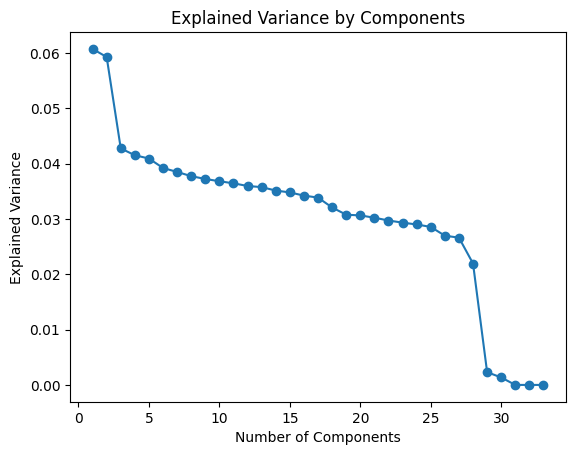

In [76]:
plt.figure()
plt.plot(range(1, len(explained_variance)+1), explained_variance, 'o-')
plt.title('Explained Variance by Components')
plt.xlabel('Number of Components')
plt.ylabel('Explained Variance')
plt.show()

Shows the individual variance contribution of each *component*

In [77]:
cumulative_variance = np.cumsum(explained_variance)

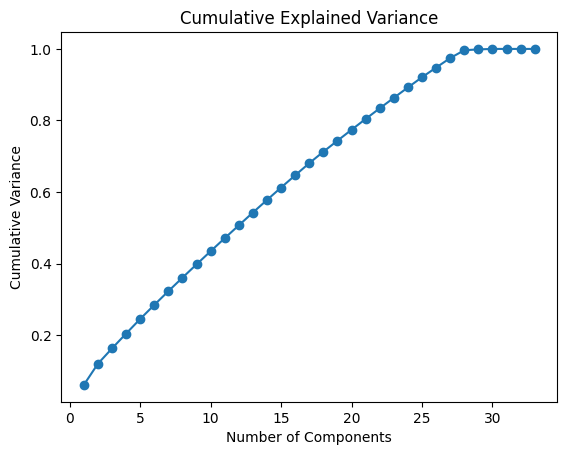

In [78]:
plt.figure()
plt.plot(range(1, len(cumulative_variance)+1), cumulative_variance, 'o-')
plt.title('Cumulative Explained Variance')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Variance')
plt.show()

In [79]:
n_components = np.argmax(cumulative_variance >= 0.95) + 1

print("Optimal number of components:", n_components)

Optimal number of components: 27


We found the 27 optimal number of components.

In [80]:
pca_final = PCA(n_components=n_components)

# Fit on train
X_train_pca = pca_final.fit_transform(X_train_scaled)

# Transform test
X_test_pca = pca_final.transform(X_test_scaled)

In [81]:
print("Train shape:", X_train_pca.shape)
print("Test shape:", X_test_pca.shape)

Train shape: (3358, 27)
Test shape: (840, 27)


## ML model building

In [82]:
model = RandomForestClassifier(
    random_state=42,
    class_weight='balanced'
)

RandomForestClassifier handles non-linear data and class imbalance.

In [83]:
model.fit(X_train_pca, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

In [84]:
y_pred = model.predict(X_test_pca)

In [87]:
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.7559523809523809

Confusion Matrix:
 [[358  31   3]
 [ 44 273   2]
 [ 72  53   4]]

Classification Report:
               precision    recall  f1-score   support

           0       0.76      0.91      0.83       392
           1       0.76      0.86      0.81       319
           2       0.44      0.03      0.06       129

    accuracy                           0.76       840
   macro avg       0.65      0.60      0.56       840
weighted avg       0.71      0.76      0.70       840



1. Accuracy is 75 % which is good.
2. CONFUSION MATRIX:

For **class 0 (low ROI)** -358 correct, It is very good at predicting LOW ROI.

for **Class 1 (Medium ROI)** - 273 correct, It is good.

for **Class 2 (HIGH ROI)** - Only 4 correct out of 129, poor performance for predicting HIGH ROI.

3. Classification Report:

Class 0 -Model is very strong for Low ROI as it have 91% correct LOW ROI value.

Class 1 - Model is very strong for Low ROI

class 2 - Almost all High ROI campaigns are missed, only 4 values are correct out of 129. Weak model for High ROI.


##**Hyperparameter Tuning**

In [89]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'class_weight': ['balanced', {0:1, 1:1, 2:3}]
}

In [91]:
grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=3,
    scoring='f1_macro',  # IMPORTANT
    n_jobs=-1
)

In [92]:
grid.fit(X_train_pca, y_train)

GridSearchCV(cv=3, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'class_weight': ['balanced', {0: 1, 1: 1, 2: 3}],
                         'max_depth': [5, 10, None], 'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 200]},
             scoring='f1_macro')

In [93]:
model = grid.best_estimator_

In [94]:
y_pred = model.predict(X_test_pca)

This uses your tuned model on test data.

In [95]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.80      0.83      0.81       392
           1       0.78      0.66      0.71       319
           2       0.24      0.31      0.27       129

    accuracy                           0.68       840
   macro avg       0.61      0.60      0.60       840
weighted avg       0.71      0.68      0.69       840



Model now detects 31% of High ROI (vs 3% earlier), There is a lot of improvement. F1 score is also incresed from 0.06 to 0.27.

In [96]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[324  22  46]
 [ 31 210  78]
 [ 52  37  40]]


Now we have 40 correct values vs before had only 4.


In [98]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.6833333333333333


Accuracy is decreased slightly but Detecting High ROI improved.

Using **Logistic Regression** for improvement.

Removing pca and using scaled data.

In [113]:
X_train_final = X_train_scaled
X_test_final = X_test_scaled

In [116]:
model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced'
)

Configured Model for improved performance.
Given maximum number of iterations for training.

class_weight- Gives more importance to minority class (Class 2). now it will focus on class 2 (HIGH ROI).


In [117]:
model.fit(X_train_final, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [118]:
y_pred = model.predict(X_test_final)

This will make predictions.

In [119]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.92      0.80      0.86       392
           1       0.92      0.80      0.85       319
           2       0.36      0.63      0.46       129

    accuracy                           0.77       840
   macro avg       0.73      0.74      0.72       840
weighted avg       0.83      0.77      0.79       840



Model now detects 63% of High ROI campaigns.

class 0 and class 1 - model predict low ROI and mediun ROI very strongly.

The final model using Logistic Regression with class balancing significantly improved recall for the high ROI category from 0.03 to 0.63, while maintaining overall accuracy.


###**summary**

In this project, a machine learning model was developed to predict the ROI category (Low, Medium, High) of marketing campaigns using pre-campaign features.

The dataset was preprocessed by handling missing values, removing duplicates, treating outliers, and encoding categorical variables. Feature engineering techniques such as extracting month information were also applied. PCA was initially explored for dimensionality reduction but later removed as it reduced model performance.

Multiple models were evaluated, and Logistic Regression with class balancing (class_weight='balanced') was selected as the final model due to its simplicity and better generalization.

The final model achieved:

Accuracy: 77%
Improved detection of High ROI campaigns (Recall: 63%)

This demonstrates that the model is effective in identifying high-performing campaigns, which is critical for business decision-making.